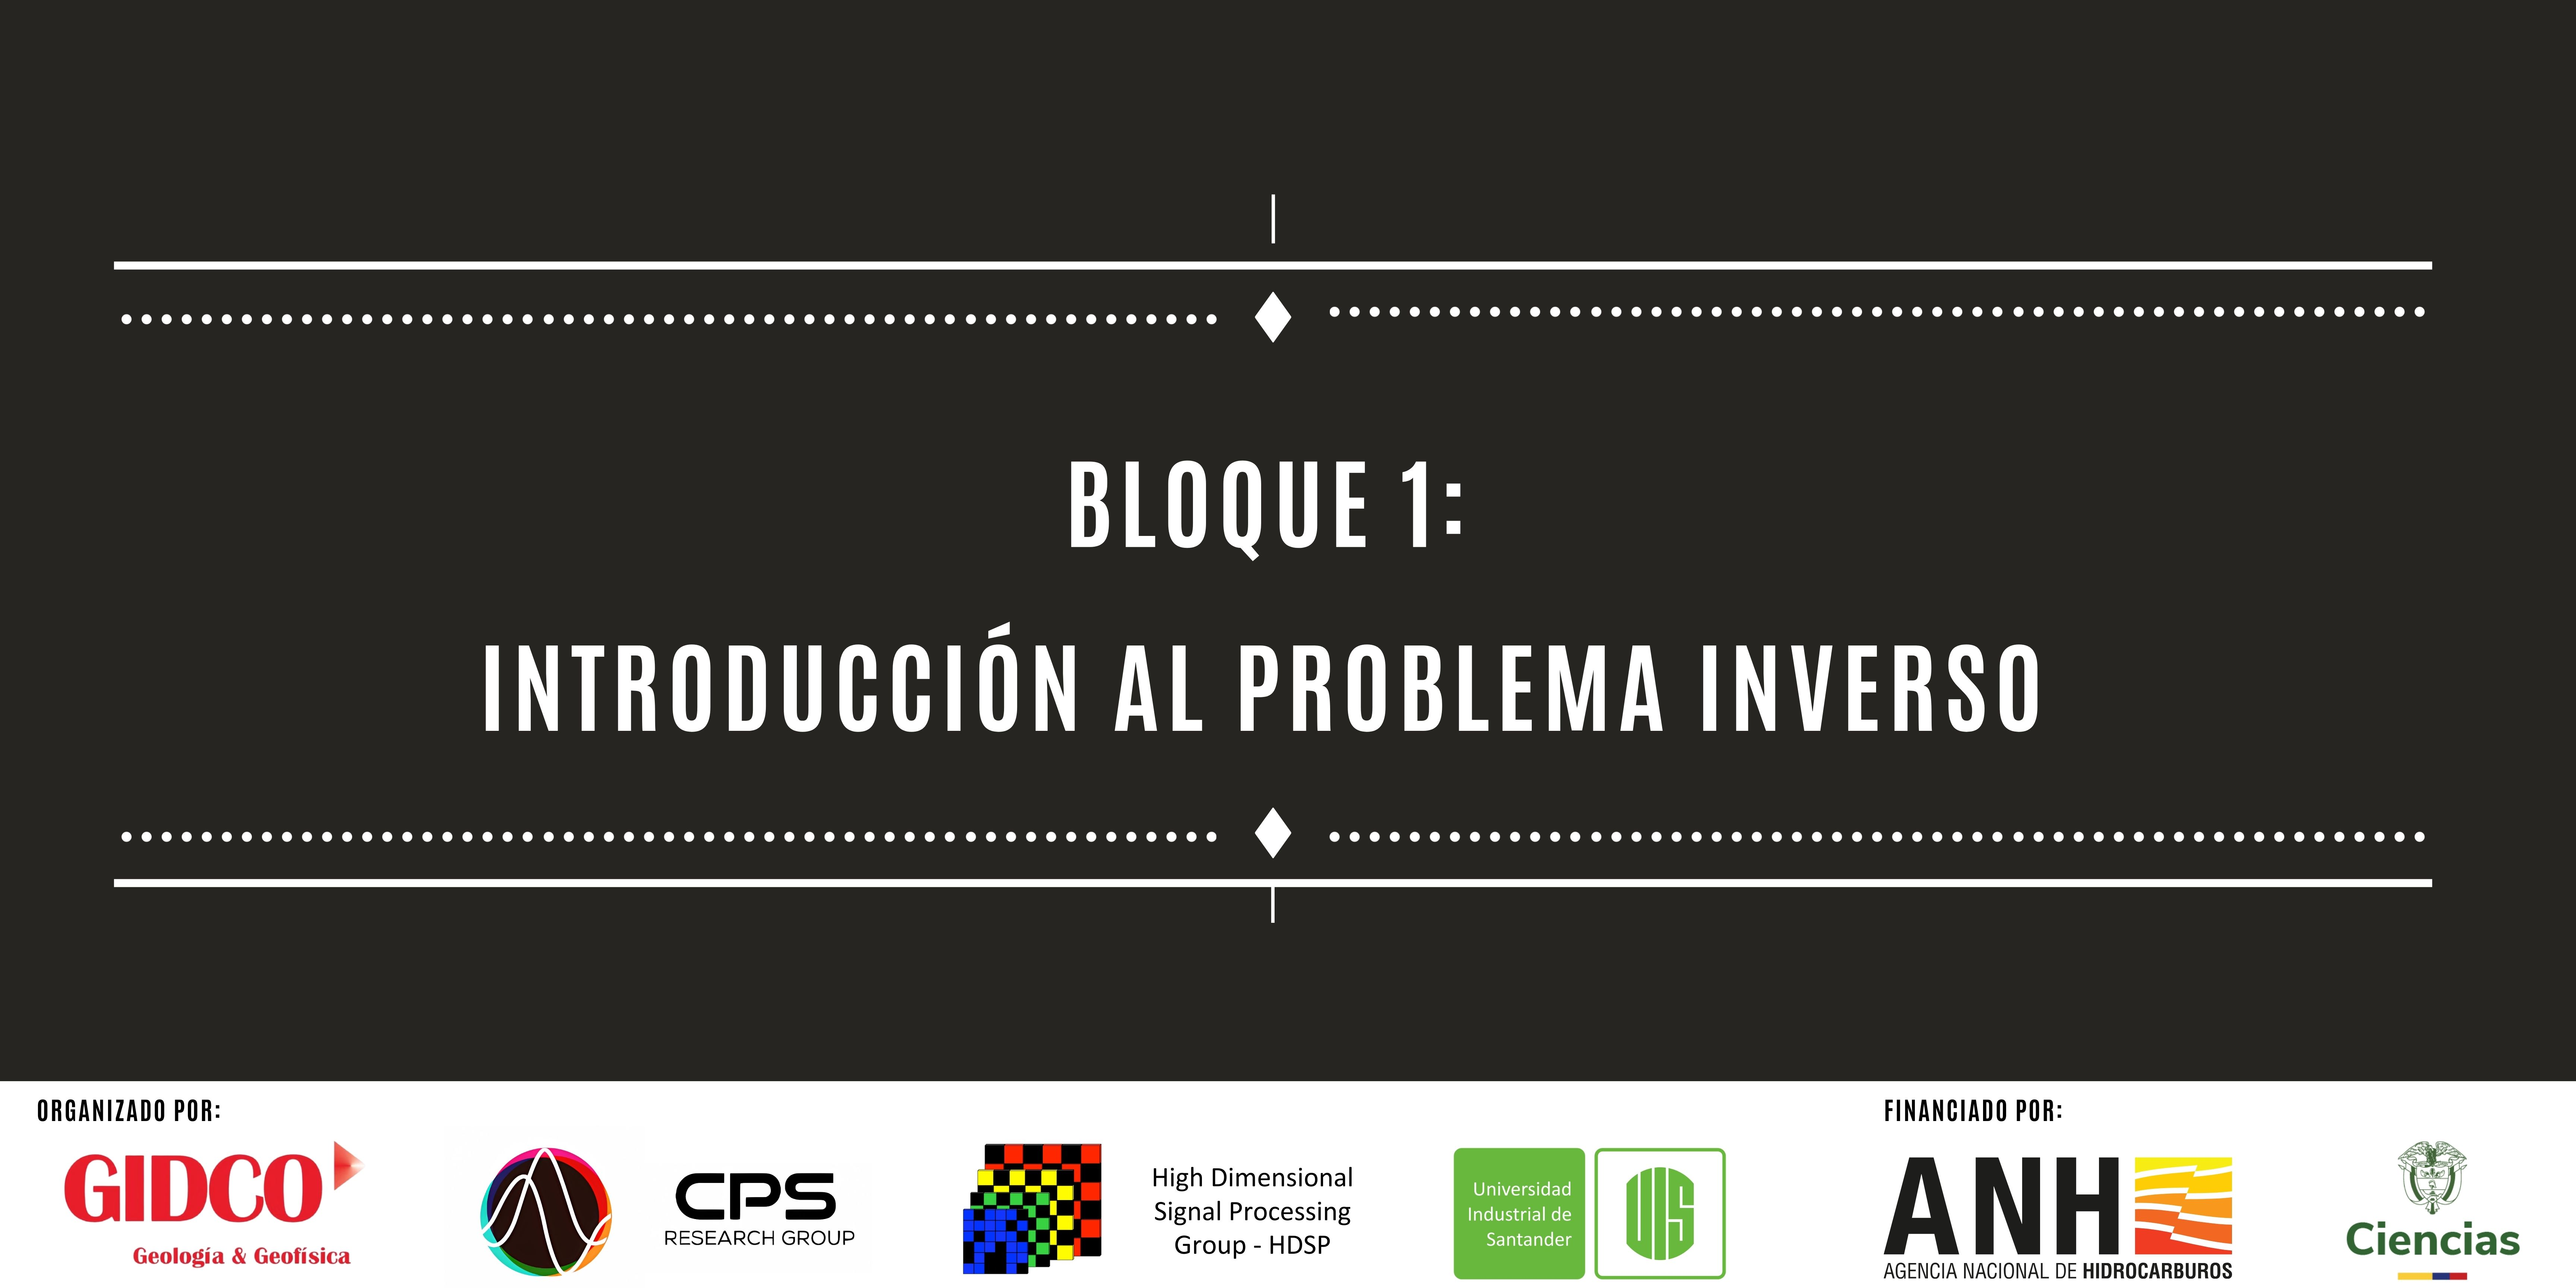

# Inversión gravimétrica mediante optimización por descenso de gradiente

## Objetivo

En este cuaderno se estudia un problema simple de inversión gravimétrica.

El subsuelo se representa mediante **tres masas puntuales enterradas** a profundidad conocida $h$, y se mide la anomalía gravimétrica vertical en **seis estaciones** ubicadas sobre la superficie.

A diferencia de una formulación matricial clásica, aquí el problema se resolverá como un problema de **optimización directa**.

Es decir, se define una función física directa:

$$
\mathbf{d}_{pred}=F(\mathbf{m})
$$

donde:

- $\mathbf{m}$ es el vector de masas desconocidas;
- $F(\mathbf{m})$ es el operador directo gravimétrico;
- $\mathbf{d}_{pred}$ son los datos predichos por el modelo.

La inversión se realiza iterativamente mediante descenso de gradiente:

1. Se propone un modelo inicial.
2. Se calcula la respuesta gravimétrica $F(\mathbf{m})$.
3. Se compara con los datos observados.
4. Se calcula el gradiente de la función objetivo.
5. Se actualizan las masas.
6. Se repite hasta reducir el desajuste.

El objetivo es encontrar un modelo $\mathbf{m}$ que reproduzca los datos observados.

In [ ]:
#@title 0) Setup

import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)

# =========================
# Constante gravitacional
# =========================
G_GRAV = 6.674e-11   # m^3 / (kg s^2)


# =========================
# Utilidades
# =========================
def build_geometry(a, h):
    station_ids = np.arange(1, 7)
    x_st = (station_ids - 1) * a

    mass_ids = np.array([1, 2, 3])
    x_m = np.array([2*a, 3*a, 4*a])   # bajo estaciones 3, 4 y 5
    z_m = -h * np.ones_like(x_m)

    return station_ids, x_st, mass_ids, x_m, z_m


def forward_gravity(m, x_st, x_m, h):
    """
    Calcula la respuesta gravimétrica vertical producida por un conjunto
    de masas puntuales enterradas.

    Parámetros
    ----------
    m : array, shape (n_masas, 1)
        Vector de masas en kg.

    x_st : array
        Posiciones horizontales de las estaciones.

    x_m : array
        Posiciones horizontales de las masas.

    h : float
        Profundidad positiva de las masas.

    Retorna
    -------
    d_pred : array, shape (n_estaciones, 1)
        Anomalía gravimétrica vertical predicha en m/s².
    """

    m = np.asarray(m).reshape(-1, 1)
    d_pred = np.zeros((len(x_st), 1))

    for i, xi in enumerate(x_st):
        gz_i = 0.0

        for j, xj in enumerate(x_m):
            dx = xi - xj
            r = np.sqrt(dx**2 + h**2)

            gz_i += G_GRAV * m[j, 0] * h / r**3

        d_pred[i, 0] = gz_i

    return d_pred


def phi_function(m, d_obs, sigma, x_st, x_m, h):
    """
    Calcula la función objetivo ponderada:

    phi(m) = 1/2 * sum [ ((d_pred - d_obs) / sigma)^2 ]
    """

    d_pred = forward_gravity(m, x_st, x_m, h)

    r = d_pred - d_obs
    r_norm = r / sigma

    phi = 0.5 * np.sum(r_norm**2)

    return float(phi)


def gradient_phi(m, d_obs, sigma, x_st, x_m, h):
    """
    Calcula el gradiente de phi respecto a las masas.

    Aunque no se construye una matriz de diseño explícita, el gradiente
    se obtiene evaluando la sensibilidad física de cada dato respecto
    a cada masa:

    ∂g_i / ∂M_j = G_GRAV * h / r_ij^3
    """

    m = np.asarray(m).reshape(-1, 1)

    d_pred = forward_gravity(m, x_st, x_m, h)
    residual = d_pred - d_obs

    grad = np.zeros_like(m)

    for j, xj in enumerate(x_m):
        grad_j = 0.0

        for i, xi in enumerate(x_st):
            dx = xi - xj
            r = np.sqrt(dx**2 + h**2)

            sensitivity_ij = G_GRAV * h / r**3

            grad_j += (residual[i, 0] / sigma[i, 0]**2) * sensitivity_ij

        grad[j, 0] = grad_j

    return grad


def parse_station_list(s):
    try:
        ids = [int(t.strip()) for t in s.split(",") if t.strip() != ""]
        ids = [i for i in ids if 1 <= i <= 6]
        ids = sorted(list(set(ids)))
        return ids if len(ids) else [1, 2, 3, 4, 5, 6]
    except Exception:
        return [1, 2, 3, 4, 5, 6]


def parse_sigma_values(mode, sigma_const, sigma_text, n=6):
    if mode == "constante":
        return sigma_const * np.ones(n)

    try:
        vals = [float(t.strip()) for t in sigma_text.split(",") if t.strip() != ""]
        if len(vals) != n:
            print("Advertencia: sigma_text no tiene 6 valores. Se usará sigma constante.")
            return sigma_const * np.ones(n)

        vals = np.array(vals, dtype=float)

        if np.any(vals <= 0):
            print("Advertencia: todas las sigmas deben ser positivas. Se usará sigma constante.")
            return sigma_const * np.ones(n)

        return vals

    except Exception:
        print("Advertencia: no se pudo leer sigma_text. Se usará sigma constante.")
        return sigma_const * np.ones(n)


print("Setup listo.")

Setup listo.


## 1) Modelo físico del subsuelo

Se asume que el subsuelo contiene tres masas puntuales:

$$
\mathbf{m} =
\begin{bmatrix}
M_1\\
M_2\\
M_3
\end{bmatrix}
$$

donde:

- $M_1$ está bajo la estación 3;
- $M_2$ está bajo la estación 4;
- $M_3$ está bajo la estación 5.

En este ejercicio, la geometría se considera conocida:

- separación entre estaciones: $a$;
- profundidad de las masas: $h$.

Por tanto, los parámetros desconocidos del problema son únicamente las tres masas.

La inversión busca estimar:

$$
M_1,\ M_2,\ M_3
$$

a partir de datos gravimétricos observados en superficie.

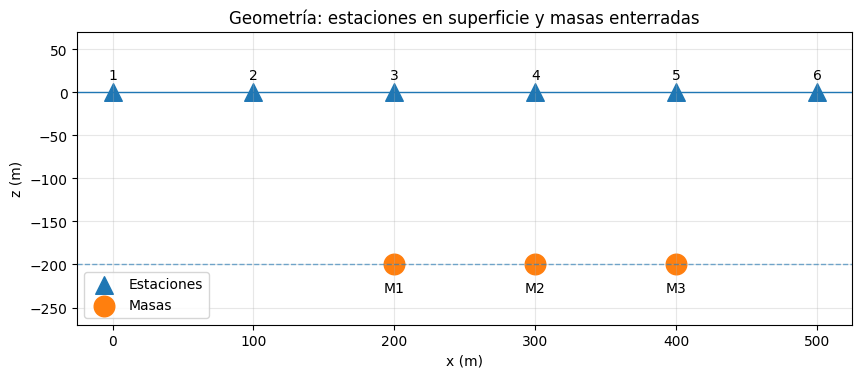

Separación entre estaciones: a = 100.0 m
Profundidad de las masas: h = 200.0 m


In [ ]:
#@title 1) Geometría del problema

a = 100.0  #@param {type:"number", min:10.0, max:2000.0, step:10.0}
h = 200.0  #@param {type:"number", min:10.0, max:2000.0, step:10.0}

show_station_labels = True  #@param {type:"boolean"}
show_mass_labels = True  #@param {type:"boolean"}

station_ids, x_st, mass_ids, x_m, z_m = build_geometry(a, h)

plt.figure(figsize=(10, 3.8))

plt.scatter(x_st, np.zeros_like(x_st), marker="^", s=160, label="Estaciones")
plt.scatter(x_m, z_m, marker="o", s=220, label="Masas")

if show_station_labels:
    for sid, xi in zip(station_ids, x_st):
        plt.text(xi, 0.06*h, f"{sid}", ha="center", va="bottom")

if show_mass_labels:
    for mid, xj in zip(mass_ids, x_m):
        plt.text(xj, -h - 0.10*h, f"M{mid}", ha="center", va="top")

plt.axhline(0, linewidth=1)
plt.axhline(-h, linewidth=1, linestyle="--", alpha=0.6)

plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("Geometría: estaciones en superficie y masas enterradas")
plt.ylim(-1.35*h, 0.35*h)
plt.legend()
plt.show()

print(f"Separación entre estaciones: a = {a:.1f} m")
print(f"Profundidad de las masas: h = {h:.1f} m")

## 2) Modelo directo gravimétrico

La contribución vertical de una masa puntual $M_j$ en una estación $i$ está dada por:

$$
g_{z,i} = \frac{G_{grav} M_j h}{r_{ij}^{3}}
$$

donde:

$$
r_{ij}=\sqrt{(x_i-x_j)^2+h^2}
$$

Como existen tres masas, la anomalía total en cada estación se obtiene sumando el efecto de todas ellas:

$$
d_i = \sum_{j=1}^{3} \frac{G_{grav} M_j h}{r_{ij}^{3}}
$$

En forma de operador directo:

$$
\mathbf{d}_{pred}=F(\mathbf{m})
$$

donde $F(\mathbf{m})$ representa el cálculo físico de la respuesta gravimétrica para un modelo dado.

En este cuaderno no se construye explícitamente una matriz de sensibilidad.  
La respuesta se calcula directamente mediante una función física forward.

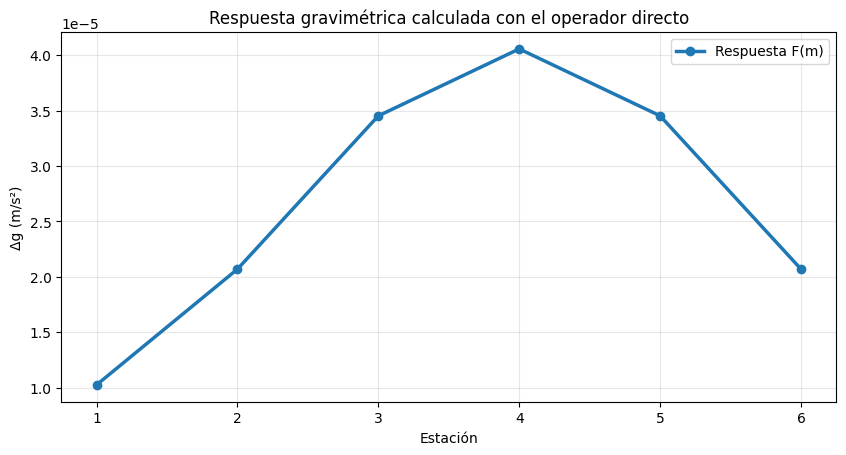

Modelo de prueba:
M1 = 1.0000e+10 kg
M2 = 1.0000e+10 kg
M3 = 1.0000e+10 kg

Respuesta predicha F(m):
Est 1: 1.023914e-05 m/s²
Est 2: 2.068560e-05 m/s²
Est 3: 3.452285e-05 m/s²
Est 4: 4.056263e-05 m/s²
Est 5: 3.452285e-05 m/s²
Est 6: 2.068560e-05 m/s²


In [ ]:
#@title 2) Probar el operador directo F(m)

M1_test = 1.0e10  #@param {type:"number", min:0.0, max:1.0e12, step:1.0e9}
M2_test = 1.0e10  #@param {type:"number", min:0.0, max:1.0e12, step:1.0e9}
M3_test = 1.0e10  #@param {type:"number", min:0.0, max:1.0e12, step:1.0e9}

m_test = np.array([[M1_test],
                   [M2_test],
                   [M3_test]], dtype=float)

d_test = forward_gravity(m_test, x_st, x_m, h).flatten()

plt.figure(figsize=(10, 4.8))
plt.plot(station_ids, d_test, marker="o", linewidth=2.5, label="Respuesta F(m)")
plt.xticks(station_ids)
plt.xlabel("Estación")
plt.ylabel("Δg (m/s²)")
plt.title("Respuesta gravimétrica calculada con el operador directo")
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.legend()
plt.show()

print("Modelo de prueba:")
print(f"M1 = {M1_test:.4e} kg")
print(f"M2 = {M2_test:.4e} kg")
print(f"M3 = {M3_test:.4e} kg")

print("\nRespuesta predicha F(m):")
for sid, val in zip(station_ids, d_test):
    print(f"Est {sid}: {val:.6e} m/s²")

## 3) Generación de datos sintéticos

Para fines didácticos, se define un modelo verdadero:

$$
\mathbf{m}_{true} =
\begin{bmatrix}
M_{1,true}\\
M_{2,true}\\
M_{3,true}
\end{bmatrix}
$$

Luego se calcula la respuesta gravimétrica verdadera mediante el operador directo:

$$
\mathbf{d}_{true}=F(\mathbf{m}_{true})
$$

Finalmente, se añade ruido gaussiano para simular datos observados:

$$
\mathbf{d}_{obs}=\mathbf{d}_{true}+\boldsymbol{\epsilon}
$$

donde $\boldsymbol{\epsilon}$ representa el ruido de medición.

In [ ]:
#@title 3) Modelo verdadero y datos observados

M1_true = 1.2e10  #@param {type:"number", min:0.0, max:1.0e12, step:1.0e9}
M2_true = 0.8e10  #@param {type:"number", min:0.0, max:1.0e12, step:1.0e9}
M3_true = 1.5e10  #@param {type:"number", min:0.0, max:1.0e12, step:1.0e9}

sigma_mode = "constante"  #@param ["constante", "manual_por_estacion"]
sigma_const = 2.0e-6  #@param {type:"number", min:1.0e-8, max:1.0e-4, step:1.0e-8}
sigma_text = "2e-6,2e-6,2e-6,2e-6,2e-6,2e-6"  #@param {type:"string"}

seed = 7  #@param {type:"integer", min:0, max:9999, step:1}

np.random.seed(seed)

m_true = np.array([[M1_true],
                   [M2_true],
                   [M3_true]], dtype=float)

d_true = forward_gravity(m_true, x_st, x_m, h)

sigma = parse_sigma_values(sigma_mode, sigma_const, sigma_text, n=6).reshape(-1, 1)

noise = np.random.normal(0.0, sigma.flatten(), size=d_true.size).reshape(-1, 1)

d_obs = d_true + noise

print("Modelo verdadero (kg):")
print(f"M1 = {M1_true:.4e}")
print(f"M2 = {M2_true:.4e}")
print(f"M3 = {M3_true:.4e}")

print("\nSigma por estación (m/s²):")
for i in range(6):
    print(f"Est {i+1}: sigma = {sigma[i,0]:.4e}")

Modelo verdadero (kg):
M1 = 1.2000e+10
M2 = 8.0000e+09
M3 = 1.5000e+10

Sigma por estación (m/s²):
Est 1: sigma = 2.0000e-06
Est 2: sigma = 2.0000e-06
Est 3: sigma = 2.0000e-06
Est 4: sigma = 2.0000e-06
Est 5: sigma = 2.0000e-06
Est 6: sigma = 2.0000e-06


## 4) Datos observados

En este gráfico se muestran únicamente los datos observados, incluyendo sus barras de incertidumbre.

Estos son los datos que se utilizarán como entrada para la inversión.

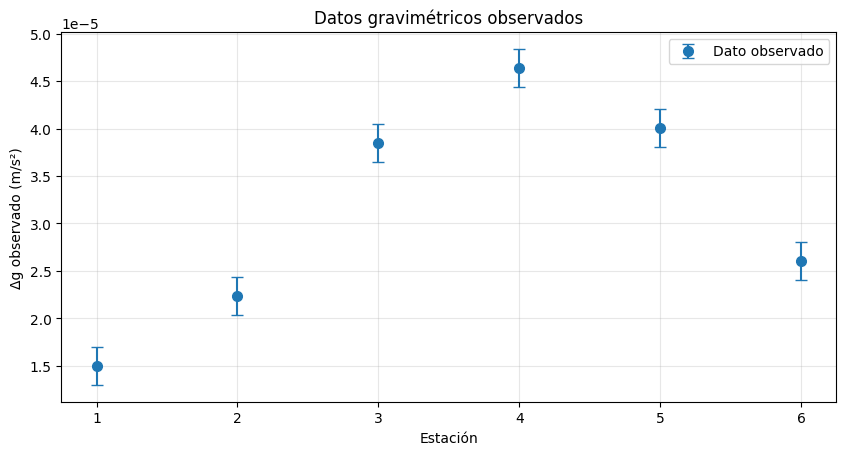

In [ ]:
#@title 4) Visualizar datos observados

plt.figure(figsize=(10, 4.8))

plt.errorbar(
    station_ids,
    d_obs.flatten(),
    yerr=sigma.flatten(),
    fmt="o",
    capsize=4,
    markersize=7,
    label="Dato observado"
)

plt.xticks(station_ids)
plt.xlabel("Estación")
plt.ylabel("Δg observado (m/s²)")
plt.title("Datos gravimétricos observados")
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.legend()
plt.show()

## 5) ¿Qué significa invertir este problema?

En la práctica, no conocemos las masas verdaderas, pero sí disponemos de datos observados:

$$
\mathbf{d}_{obs}
$$

La inversión consiste en encontrar un modelo $\mathbf{m}$ tal que su respuesta física:

$$
\mathbf{d}_{pred}=F(\mathbf{m})
$$

se parezca lo mejor posible a los datos observados.

Para medir el desajuste se define la función objetivo ponderada:

$$
\phi(\mathbf{m})=
\frac{1}{2}
\sum_{i=1}^{N}
\left(
\frac{d_{pred,i}-d_{obs,i}}{\sigma_i}
\right)^2
$$

donde:

- $d_{pred,i}$ es el dato predicho en la estación $i$;
- $d_{obs,i}$ es el dato observado en la estación $i$;
- $\sigma_i$ es la incertidumbre del dato observado.

Cuanto menor sea $\phi(\mathbf{m})$, mejor reproduce el modelo los datos observados.

## 6) Gradiente de la función objetivo

La función objetivo es:

$$
\phi(\mathbf{m})=
\frac{1}{2}
\sum_{i=1}^{N}
\left(
\frac{F_i(\mathbf{m})-d_{obs,i}}{\sigma_i}
\right)^2
$$

Para actualizar las masas se necesita el gradiente:

$$
\nabla \phi(\mathbf{m})
$$

Este gradiente indica cómo debe cambiar cada masa para reducir el desajuste.

En este ejercicio, el gradiente se calcula usando la sensibilidad física de cada estación respecto a cada masa:

$$
\frac{\partial g_i}{\partial M_j}
=
\frac{G_{grav}h}{r_{ij}^{3}}
$$

donde:

$$
r_{ij}=\sqrt{(x_i-x_j)^2+h^2}
$$

Por tanto, el gradiente respecto a la masa $M_j$ es:

$$
\frac{\partial \phi}{\partial M_j}
=
\sum_{i=1}^{N}
\frac{d_{pred,i}-d_{obs,i}}{\sigma_i^2}
\frac{\partial g_i}{\partial M_j}
$$

La inversión se resuelve actualizando el modelo en dirección opuesta al gradiente.

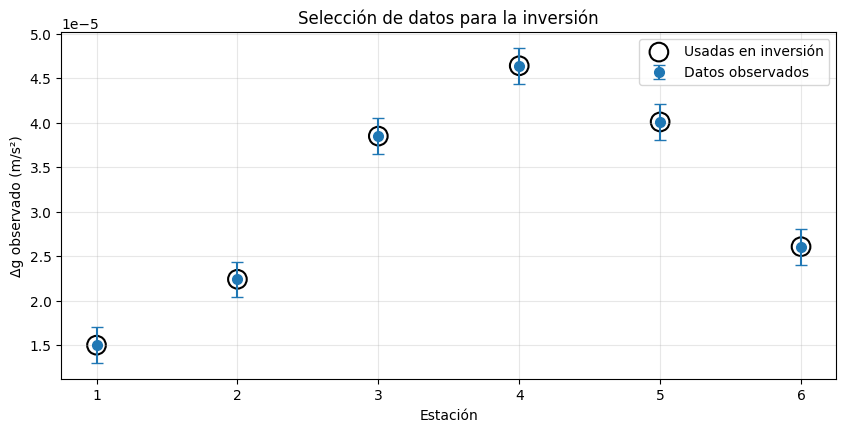

Estaciones usadas: [1, 2, 3, 4, 5, 6]
Número de datos usados: 6


In [ ]:
#@title 7) Selección de estaciones para invertir

stations_for_inversion = "1,2,3,4,5,6"  #@param {type:"string"}
show_used_stations = True  #@param {type:"boolean"}

inv_ids = parse_station_list(stations_for_inversion)
inv_idx = np.array([i-1 for i in inv_ids], dtype=int)

x_st_inv = x_st[inv_idx]
station_ids_inv = station_ids[inv_idx]

d_inv = d_obs[inv_idx]
sigma_inv = sigma[inv_idx]

plt.figure(figsize=(10, 4.5))

plt.errorbar(
    station_ids,
    d_obs.flatten(),
    yerr=sigma.flatten(),
    fmt="o",
    capsize=4,
    markersize=7,
    label="Datos observados"
)

if show_used_stations:
    plt.scatter(
        station_ids_inv,
        d_obs[inv_idx].flatten(),
        s=180,
        facecolors="none",
        edgecolors="k",
        linewidths=1.5,
        label="Usadas en inversión"
    )

plt.xticks(station_ids)
plt.xlabel("Estación")
plt.ylabel("Δg observado (m/s²)")
plt.title("Selección de datos para la inversión")
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.legend()
plt.show()

print("Estaciones usadas:", inv_ids)
print(f"Número de datos usados: {len(inv_ids)}")

## 8) Esquema iterativo de descenso de gradiente

La actualización del modelo se realiza mediante:

$$
\mathbf{m}^{(k+1)}
=
\mathbf{m}^{(k)}
-
\alpha
\nabla \phi(\mathbf{m}^{(k)})
$$

donde:

- $\mathbf{m}^{(k)}$ es el modelo en la iteración $k$;
- $\alpha$ es la tasa de aprendizaje;
- $\nabla \phi(\mathbf{m}^{(k)})$ es el gradiente de la función objetivo.

La idea física es simple:

- si el modelo actual no reproduce bien los datos observados;
- se calcula cómo debe modificarse cada masa;
- se actualiza el modelo;
- se repite el proceso hasta reducir $\phi(\mathbf{m})$.

In [ ]:
#@title 9) Ejecutar descenso de gradiente

# Modelo inicial
M1_init = 0.0  #@param {type:"number", min:-1.0e11, max:1.0e12, step:1.0e9}
M2_init = 0.0  #@param {type:"number", min:-1.0e11, max:1.0e12, step:1.0e9}
M3_init = 0.0  #@param {type:"number", min:-1.0e11, max:1.0e12, step:1.0e9}

# Control de iteración
n_iter = 300  #@param {type:"integer", min:1, max:20000, step:1}

# Tasa de aprendizaje
lr_mode = "auto"  #@param ["auto", "manual"]
alpha_manual = 1.0e21  #@param {type:"number", min:1.0e1, max:1.0e25, step:1.0e18}
lr_auto_factor = 0.90  #@param {type:"number", min:0.01, max:1.99, step:0.01}

# Modelo inicial
m_est = np.array([[M1_init],
                  [M2_init],
                  [M3_init]], dtype=float)

# ---------------------------------------------------------
# Estimación automática de alpha sin construir matriz G.
# Se calcula la curvatura aproximada evaluando sensibilidades
# de manera directa.
# ---------------------------------------------------------
sens_norm = 0.0

for j, xj in enumerate(x_m):
    for i, xi in enumerate(x_st_inv):
        dx = xi - xj
        r = np.sqrt(dx**2 + h**2)

        sensitivity_ij = G_GRAV * h / r**3
        sens_norm += (sensitivity_ij / sigma_inv[i, 0])**2

if lr_mode == "auto":
    alpha = lr_auto_factor / max(sens_norm, 1e-30)
else:
    alpha = alpha_manual

# Historial
phi_history = [
    phi_function(m_est, d_inv, sigma_inv, x_st_inv, x_m, h)
]

m1_history = [float(m_est[0, 0])]
m2_history = [float(m_est[1, 0])]
m3_history = [float(m_est[2, 0])]

progress = trange(n_iter, desc="Invirtiendo")
update_every = max(1, n_iter // 25)

for k in progress:

    grad = gradient_phi(m_est, d_inv, sigma_inv, x_st_inv, x_m, h)

    m_est = m_est - alpha * grad

    phi_now = phi_function(m_est, d_inv, sigma_inv, x_st_inv, x_m, h)

    phi_history.append(phi_now)

    m1_history.append(float(m_est[0, 0]))
    m2_history.append(float(m_est[1, 0]))
    m3_history.append(float(m_est[2, 0]))

    if (k % update_every == 0) or (k == n_iter - 1):
        progress.set_postfix({
            "phi": f"{phi_now:.3e}",
            "M1": f"{m_est[0,0]:.2e}",
            "M2": f"{m_est[1,0]:.2e}",
            "M3": f"{m_est[2,0]:.2e}"
        })

# Respuesta final para todas las estaciones
d_pred = forward_gravity(m_est, x_st, x_m, h)

# Residuos para todas las estaciones
r_all = d_obs - d_pred

# Métricas finales usando solo estaciones invertidas
d_pred_inv = forward_gravity(m_est, x_st_inv, x_m, h)

phi_final = phi_function(m_est, d_inv, sigma_inv, x_st_inv, x_m, h)

dof = max(len(inv_ids) - 3, 1)
chi2_red = 2.0 * phi_final / dof

print("Resultado final:")
print("-" * 55)
print(f"alpha = {alpha:.6e}")
print(f"M1_est = {m_est[0,0]:.6e} kg")
print(f"M2_est = {m_est[1,0]:.6e} kg")
print(f"M3_est = {m_est[2,0]:.6e} kg")
print(f"phi_final = {phi_final:.6e}")
print(f"chi2_red = {chi2_red:.6e}")
print("-" * 55)

Invirtiendo: 100%|██████████| 300/300 [00:00<00:00, 4320.30it/s, phi=1.744e+00, M1=1.19e+10, M2=9.16e+09, M3=1.37e+10]

Resultado final:
-------------------------------------------------------
alpha = 1.903826e+17
M1_est = 1.193437e+10 kg
M2_est = 9.160451e+09 kg
M3_est = 1.374465e+10 kg
phi_final = 1.743526e+00
chi2_red = 1.162350e+00
-------------------------------------------------------


## 10) Evolución de la función objetivo

Este gráfico muestra cómo cambia:

$$
\phi(\mathbf{m}^{(k)})
$$

a lo largo de las iteraciones.

Si el método está funcionando correctamente, la función objetivo debería disminuir progresivamente.

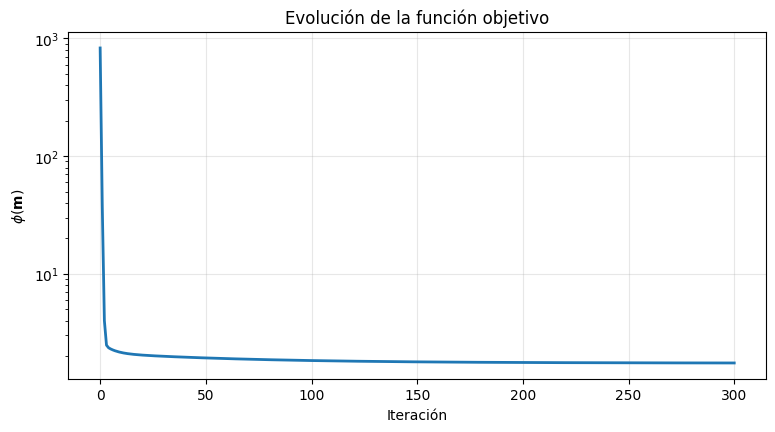

In [ ]:
#@title 11) Historia de la función objetivo

plt.figure(figsize=(9, 4.5))

plt.plot(phi_history, linewidth=2)

plt.xlabel("Iteración")
plt.ylabel(r"$\phi(\mathbf{m})$")
plt.yscale("log")
plt.title("Evolución de la función objetivo")
plt.show()

## 12) Evolución del modelo

Además de la función objetivo, es útil observar cómo cambian las tres masas durante la inversión.

Esto permite ver si el modelo se estabiliza y hacia qué valores converge.

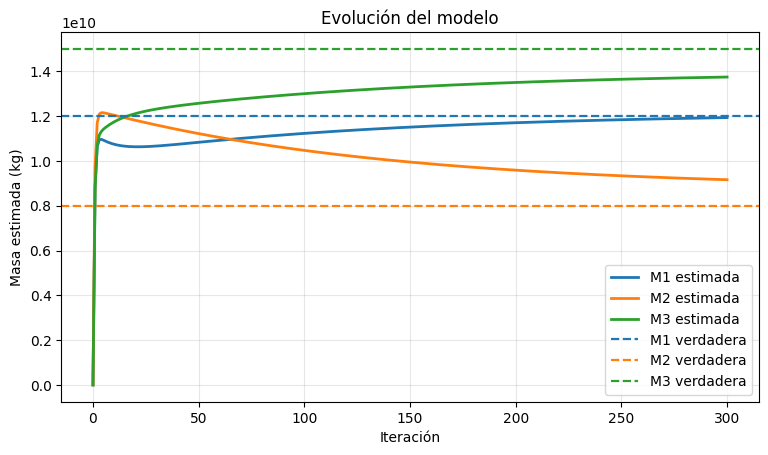

In [ ]:
#@title 13) Evolución de M1, M2 y M3

show_true_lines = True  #@param {type:"boolean"}

plt.figure(figsize=(9, 4.8))

plt.plot(m1_history, linewidth=2, color="tab:blue", label="M1 estimada")
plt.plot(m2_history, linewidth=2, color="tab:orange", label="M2 estimada")
plt.plot(m3_history, linewidth=2, color="tab:green", label="M3 estimada")

if show_true_lines:
    plt.axhline(M1_true, linestyle="--", linewidth=1.6, color="tab:blue", label="M1 verdadera")
    plt.axhline(M2_true, linestyle="--", linewidth=1.6, color="tab:orange", label="M2 verdadera")
    plt.axhline(M3_true, linestyle="--", linewidth=1.6, color="tab:green", label="M3 verdadera")

plt.xlabel("Iteración")
plt.ylabel("Masa estimada (kg)")
plt.title("Evolución del modelo")
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.legend()
plt.show()

## 14) Ajuste final en el espacio de datos

Una vez obtenido el modelo estimado, se calcula su respuesta física:

$$
\mathbf{d}_{pred}=F(\mathbf{m}_{est})
$$

Este gráfico compara:

- los datos observados;
- los datos predichos por el modelo invertido.

Si la inversión fue exitosa, la curva predicha debe acercarse a los datos observados dentro de sus barras de error.

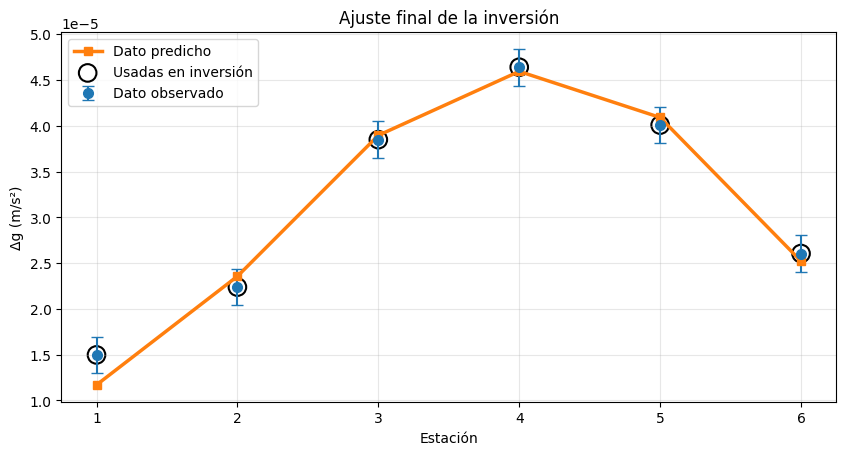

In [ ]:
#@title 15) Datos observados vs datos predichos

plt.figure(figsize=(10, 4.8))

plt.errorbar(
    station_ids,
    d_obs.flatten(),
    yerr=sigma.flatten(),
    fmt="o",
    capsize=4,
    markersize=7,
    label="Dato observado"
)

plt.plot(
    station_ids,
    d_pred.flatten(),
    marker="s",
    linewidth=2.5,
    label="Dato predicho"
)

plt.scatter(
    station_ids_inv,
    d_obs[inv_idx].flatten(),
    s=160,
    facecolors="none",
    edgecolors="k",
    linewidths=1.5,
    label="Usadas en inversión"
)

plt.xticks(station_ids)
plt.xlabel("Estación")
plt.ylabel("Δg (m/s²)")
plt.title("Ajuste final de la inversión")
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.legend()
plt.show()

## 16) Residuos

Los residuos se definen como:

$$
\mathbf{r}=\mathbf{d}_{obs}-\mathbf{d}_{pred}
$$

Este gráfico permite identificar en qué estaciones el modelo ajusta mejor o peor los datos.

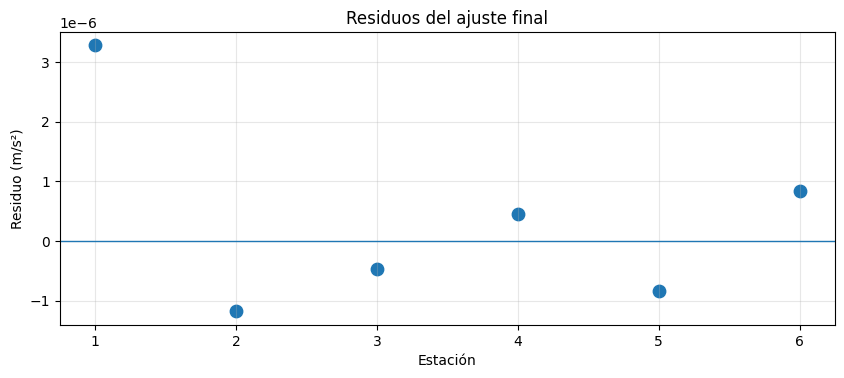

In [ ]:
#@title 17) Residuos por estación

plt.figure(figsize=(10, 3.8))

plt.axhline(0, linewidth=1)
plt.scatter(station_ids, r_all.flatten(), s=80)

plt.xticks(station_ids)
plt.xlabel("Estación")
plt.ylabel("Residuo (m/s²)")
plt.title("Residuos del ajuste final")
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.show()

## 18) Comparación entre modelo verdadero y modelo estimado

Como este ejemplo es sintético, sí conocemos el modelo verdadero. Por eso se puede comparar directamente la inversión con las masas usadas para generar los datos.

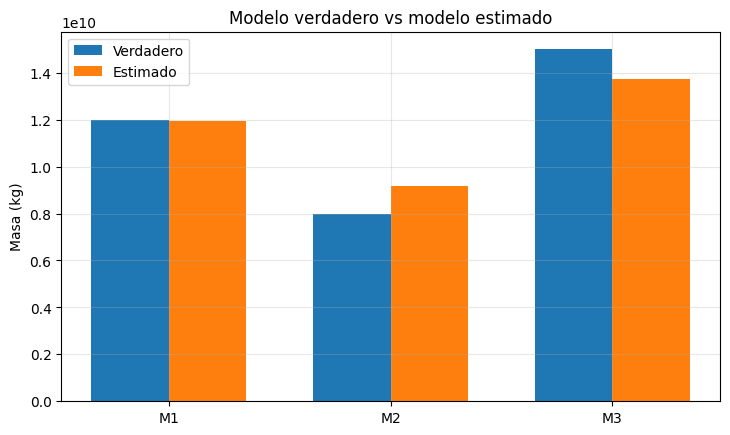

Resumen numérico
------------------------------------------------------------
Parámetro         Verdadero (kg)         Estimado (kg)
------------------------------------------------------------
M1                  1.200000e+10          1.193437e+10
M2                  8.000000e+09          9.160451e+09
M3                  1.500000e+10          1.374465e+10
------------------------------------------------------------

Resumen de ajuste
------------------------------------------------------------
phi final                   1.743526e+00
chi2 reducido               1.162350e+00
------------------------------------------------------------


In [ ]:
#@title 19) Comparación de masas

labels = ["M1", "M2", "M3"]
xpos = np.arange(3)
width = 0.35

true_vals = np.array([M1_true, M2_true, M3_true])
est_vals = m_est.flatten()

plt.figure(figsize=(8.5, 4.8))

plt.bar(xpos - width/2, true_vals, width=width, label="Verdadero")
plt.bar(xpos + width/2, est_vals, width=width, label="Estimado")

plt.xticks(xpos, labels)
plt.ylabel("Masa (kg)")
plt.title("Modelo verdadero vs modelo estimado")
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.legend()
plt.show()

print("Resumen numérico")
print("-" * 60)
print(f"{'Parámetro':<10}{'Verdadero (kg)':>22}{'Estimado (kg)':>22}")
print("-" * 60)
print(f"{'M1':<10}{M1_true:>22.6e}{m_est[0,0]:>22.6e}")
print(f"{'M2':<10}{M2_true:>22.6e}{m_est[1,0]:>22.6e}")
print(f"{'M3':<10}{M3_true:>22.6e}{m_est[2,0]:>22.6e}")
print("-" * 60)

print("\nResumen de ajuste")
print("-" * 60)
print(f"{'phi final':<20}{phi_final:>20.6e}")
print(f"{'chi2 reducido':<20}{chi2_red:>20.6e}")
print("-" * 60)

## 20) Preguntas de exploración

### Sobre los datos

- ¿Qué ocurre al aumentar la incertidumbre `sigma_const`?
- ¿Qué pasa si se usa solo una parte de las estaciones?
- ¿Qué estaciones aportan más información para estimar las masas?

### Sobre el modelo directo

- ¿Cómo cambia la anomalía gravimétrica cuando aumenta la profundidad $h$?
- ¿Qué ocurre si las masas están más separadas?
- ¿Por qué la respuesta gravimétrica disminuye con la distancia?

### Sobre el descenso de gradiente

- ¿Qué ocurre si el modelo inicial está muy lejos del modelo verdadero?
- ¿Qué pasa si el número de iteraciones es muy pequeño?
- ¿Qué ocurre si la tasa de aprendizaje es demasiado pequeña?
- ¿Qué ocurre si la tasa de aprendizaje es demasiado grande?

### Sobre la inversión

- ¿Por qué la inversión busca minimizar $\phi(\mathbf{m})$?
- ¿Qué significa que los residuos sean pequeños?
- ¿Por qué diferentes modelos pueden producir respuestas similares?
- ¿Qué ventaja tiene resolver el problema como optimización iterativa?